
# Modelljämförelse - Azar's branch

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import recall_score, precision_score, roc_auc_score, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

In [36]:
path = "/Users/azarmohseni/Desktop/Grupparbete_ML_Grupp_6/Data/historical_data.csv"
df = pd.read_csv(path)

print(f"{df.shape[0]} rader, {df.shape[1]} kolumner")
print(f"\nTarget-fördelning:")
print(df["is_suspicious"].value_counts())

12000 rader, 18 kolumner

Target-fördelning:
is_suspicious
0    10776
1     1224
Name: count, dtype: int64


### Separera features och target och Train/Test Split 80/20 

In [39]:
target_column = "is_suspicious"
X = df.drop(columns=[target_column, "id"]) 
y = df[target_column]

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,  
    random_state=42
)

print(f"Train set: {X_train.shape[0]} (klass fördelning: {y_train.value_counts().to_dict()})")
print(f"Test set: {X_test.shape[0]} (klass fördelning: {y_test.value_counts().to_dict()})")

X shape: (12000, 16)
y shape: (12000,)
Train set: 9600 (klass fördelning: {0: 8621, 1: 979})
Test set: 2400 (klass fördelning: {0: 2155, 1: 245})


### Preproccesing pipeline 

In [32]:
categorical_features = [
    "event_type",
    "category",
    "region",
    "device"
]

numeric_features = [
    "day",
    "account_age_days",
    "num_prev_listings",
    "prev_reports_30d",
    "price",
    "num_images",
    "verification_level",
    "contains_off_platform",
    "urgency_words",
    "payment_attempt",
    "message_length",
    "time_to_first_response_min"
]

print(f"Kategoriska features: {len(categorical_features)}")
print(f"Numeriska features: {len(numeric_features)}")

# Numeriska transformer
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Kategoriska transformer
categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

# Båda
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("Preprocessing pipeline skapad")

Kategoriska features: 4
Numeriska features: 12
Preprocessing pipeline skapad


## 3 modeller
### Baseline + 2 andra

In [31]:
models = {
    "Baseline (Dummy Classifier)": DummyClassifier(strategy="most_frequent", random_state=42),
    
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42,
        class_weight="balanced" 
    ),
    
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        max_depth=10,
        class_weight="balanced", 
        n_jobs=-1  
    )
}

print(f"{len(models)} modeller definierade:")
for name in models.keys():
    print(f"  - {name}")

3 modeller definierade:
  - Baseline (Dummy Classifier)
  - Logistic Regression
  - Random Forest


### CV Setup

In [29]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

print(f"Stratified K-Fold CV (5 splits)")

Stratified K-Fold CV (5 splits)


### Träna alla modeller

In [20]:
metrics_to_calculate = {
    "recall": "recall",      
    "roc_auc": "roc_auc",    
    "precision": "precision" 
}

print(f"Metriker som beräknas:")
print(f"  - Recall (PRIMÄR): Fångar vi misstänkta fall?")
print(f"  - ROC-AUC (SEKUNDÄR): Generell klassificeringsförmåga")
print(f"  - Precision: Av dem vi flaggade, hur många var faktiskt misstänkta?")

Metriker som beräknas:
  - Recall (PRIMÄR): Fångar vi misstänkta fall?
  - ROC-AUC (SEKUNDÄR): Generell klassificeringsförmåga
  - Precision: Av dem vi flaggade, hur många var faktiskt misstänkta?


In [25]:
results = {}

print("\n")
print("EVALUERING PÅ GÅNG")
for model_name, model in models.items():
    print(f"\n Testar: {model_name}")
    
    
    full_pipeline = Pipeline([
        ("preprocessing", preprocessor),
        ("model", model)
    ])
    
    
    model_results = {}
    
    for metric_display_name, metric_sklearn in metrics_to_calculate.items():
        cv_scores = cross_val_score(
            full_pipeline,
            X_train,
            y_train,
            cv=cv,
            scoring=metric_sklearn,
            n_jobs=-1
        )
        
        model_results[metric_display_name] = {
            "mean": cv_scores.mean(),
            "std": cv_scores.std(),
            "scores": cv_scores
        }
        
        print(f"  {metric_display_name.upper():12} = {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")
    
    results[model_name] = model_results

print("\n")



EVALUERING PÅ GÅNG

 Testar: Baseline (Dummy Classifier)
  RECALL       = 0.0000 (+/- 0.0000)
  ROC_AUC      = 0.5000 (+/- 0.0000)
  PRECISION    = 0.0000 (+/- 0.0000)

 Testar: Logistic Regression
  RECALL       = 0.6517 (+/- 0.0258)
  ROC_AUC      = 0.7359 (+/- 0.0207)
  PRECISION    = 0.1929 (+/- 0.0064)

 Testar: Random Forest
  RECALL       = 0.2390 (+/- 0.0112)
  ROC_AUC      = 0.7117 (+/- 0.0081)
  PRECISION    = 0.2447 (+/- 0.0107)




### Sammanfattning

In [28]:
results_summary = pd.DataFrame({
    model_name: {
        "Recall (mean)": results[model_name]["recall"]["mean"],
        "Recall (std)": results[model_name]["recall"]["std"],
        "ROC-AUC (mean)": results[model_name]["roc_auc"]["mean"],
        "ROC-AUC (std)": results[model_name]["roc_auc"]["std"],
        "Precision (mean)": results[model_name]["precision"]["mean"],
        "Precision (std)": results[model_name]["precision"]["std"],
    }
    for model_name in models.keys()
}).T

results_summary = results_summary.round(4)

print("\n JÄMFÖRELSE AV ALLA MODELLER:\n")
print(results_summary)

results_summary.to_csv("model_comparison_results.csv")
print("\nResultat sparade till: model_comparison_results.csv")


 JÄMFÖRELSE AV ALLA MODELLER:

                             Recall (mean)  Recall (std)  ROC-AUC (mean)  \
Baseline (Dummy Classifier)         0.0000        0.0000          0.5000   
Logistic Regression                 0.6517        0.0258          0.7359   
Random Forest                       0.2390        0.0112          0.7117   

                             ROC-AUC (std)  Precision (mean)  Precision (std)  
Baseline (Dummy Classifier)         0.0000            0.0000           0.0000  
Logistic Regression                 0.0207            0.1929           0.0064  
Random Forest                       0.0081            0.2447           0.0107  

Resultat sparade till: model_comparison_results.csv


### Modelljämförelse 

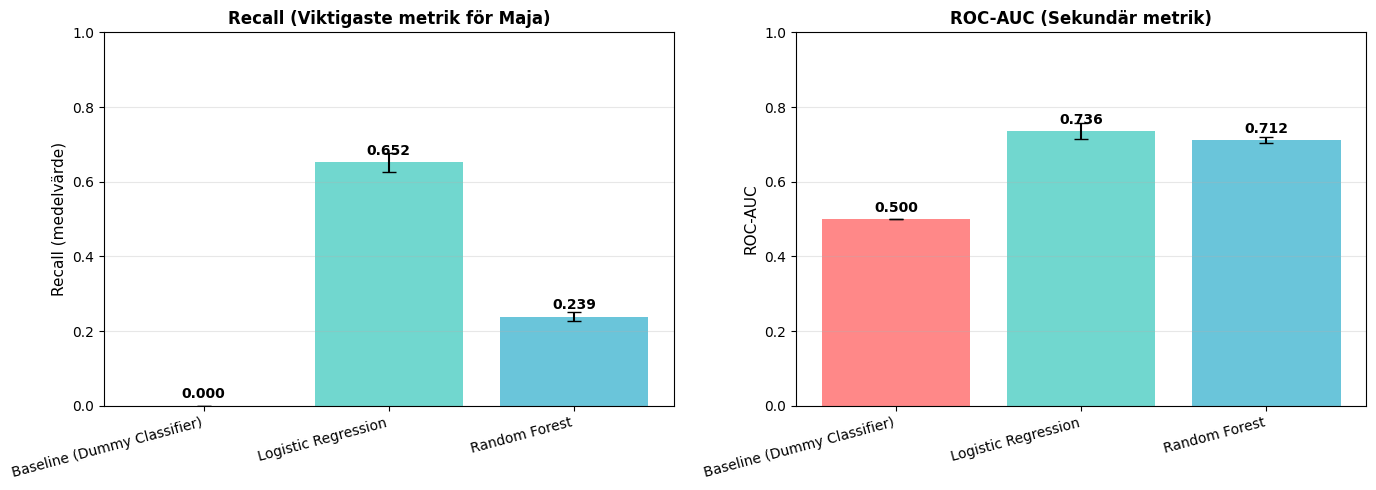

Figur sparad oi model_comparison_visualization.png


In [40]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

recall_values = [results[name]["recall"]["mean"] for name in models.keys()]
recall_stds = [results[name]["recall"]["std"] for name in models.keys()]
model_names = list(models.keys())

axes[0].bar(range(len(model_names)), recall_values, yerr=recall_stds, capsize=5, color=['#FF6B6B', '#4ECDC4', '#45B7D1'], alpha=0.8)
axes[0].set_xticks(range(len(model_names)))
axes[0].set_xticklabels(model_names, rotation=15, ha="right")
axes[0].set_ylabel("Recall (medelvärde)", fontsize=11)
axes[0].set_title("Recall (Viktigaste metrik för Maja)", fontsize=12, fontweight="bold")
axes[0].set_ylim([0, 1])
axes[0].grid(axis="y", alpha=0.3)

for i, v in enumerate(recall_values):
    axes[0].text(i, v + 0.02, f"{v:.3f}", ha="center", fontsize=10, fontweight="bold")

roc_auc_values = [results[name]["roc_auc"]["mean"] for name in models.keys()]
roc_auc_stds = [results[name]["roc_auc"]["std"] for name in models.keys()]

axes[1].bar(range(len(model_names)), roc_auc_values, yerr=roc_auc_stds, capsize=5, color=['#FF6B6B', '#4ECDC4', '#45B7D1'], alpha=0.8)
axes[1].set_xticks(range(len(model_names)))
axes[1].set_xticklabels(model_names, rotation=15, ha="right")
axes[1].set_ylabel("ROC-AUC", fontsize=11)
axes[1].set_title("ROC-AUC (Sekundär metrik)", fontsize=12, fontweight="bold")
axes[1].set_ylim([0, 1])
axes[1].grid(axis="y", alpha=0.3)

for i, v in enumerate(roc_auc_values):
    axes[1].text(i, v + 0.02, f"{v:.3f}", ha="center", fontsize=10, fontweight="bold")

plt.tight_layout()
plt.savefig("model_comparison_visualization.png", dpi=300, bbox_inches="tight")
plt.show()

print("Figur sparad oi model_comparison_visualization.png")

## Vinnare och Analys

Logistic Regression är bäst för Majas behov.

**Recall: 0.6517** betyder vi fångar ca 65% av misstänkta fall.

Varför inte Random Forest? 
- Recall var bara 0.2390 - för lågt för Maja
- Logistic Regression är mycket enklare att förklara
- Vi kan säga: "Högre risk-poäng = mer misstänkt" 

Det passar Majas behov perfekt.


### Trade-offs: 
   Recall vs Precision:
   - Vi väljer högt Recall (fånga misstänkta)
   - Det betyder färre False Negatives (misstänkta som glider igenom)
   - Men mer False Positives (icke-misstänkta som flaggas)